In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mpas_tools

from geometric_features import GeometricFeatures
from geometric_features import read_feature_collection

from mpas_tools.mesh.mask import compute_mpas_region_masks
from mpas_tools.parallel import create_pool
from mpas_tools.io import write_netcdf

import geojson
import json
import mosaic
import os.path
import mpasregions.sections as mps
import warnings
import glob
import mpasregions.transects_MPAS as ben


from shapely.geometry import shape, Polygon, MultiPolygon, box, mapping
from shapely.ops import unary_union
from shapely.affinity import translate
from shapely.validation import make_valid, explain_validity
from geometric_features import FeatureCollection
from shapely.geometry.polygon import orient


## Build two feature collections that do not cross the anti-meridian (180deg)

In [3]:
# POLYGON 1
coordinates_P1 = [
    # outer circle
    [-180,-30],[-90,-30],[0,-30],[90,-30],
    # inner circle
    [90,-80],[0,-80],[-90,-80],[-180,-80],
    # close the polygon
    [-180, -30]
]

# POLYGON 2
coordinates_P2 = [
    # outer circle
    [90,-30],[180,-30],
    # inner circle
    [180, -80],[90, -80],
    # close the polygon
    [90, -30]
]

In [4]:
# create two separate feature collections
fc_P1 = FeatureCollection()
feature_P1 = {
          "type": "Feature",
          "properties": {
              "name": 'Polygon 1',
              "component": 'ocean',
              "object": 'region',
              "tags": 'custom'
      },
      "geometry": {
          "type": "Polygon",
          "coordinates": [coordinates_P1
        ]
      }
    }
fc_P1.add_feature(feature_P1)

fc_P2 = FeatureCollection()
feature_P2 = {
          "type": "Feature",
          "properties": {
              "name": 'Polygon 1',
              "component": 'ocean',
              "object": 'region',
              "tags": 'custom'
      },
      "geometry": {
          "type": "Polygon",
          "coordinates": [coordinates_P2
        ]
      }
    }
fc_P2.add_feature(feature_P2)

## Combine feature collections into 1 multipolygon

In [5]:
# combine the geometries
fcs = [fc_P1, fc_P2]
geometries = []

for i in range(0,len(fcs)):
    geometries = np.append(geometries, shape(fcs[i].features[0]['geometry']))

fc_MP = FeatureCollection()

feature_MP = {
    "type": "Feature",
    "properties": {
        "name": 'MultiPolygon',
        "component": 'ocean',
        "object": 'region',
        "tags": 'custom'
    },
    "geometry": mapping(MultiPolygon(geometries))
}

fc_MP.add_feature(feature_MP)
fcMask = fc_MP

In [6]:
print(geometries[0].is_valid, geometries[1].is_valid)
print(explain_validity(geometries[0]))

True True
Valid Geometry


## Use feature collection MultiPolygon to create a region mask using ```compute_region_masks```

In [7]:
mesh_path = '/global/cfs/projectdirs/e3sm/inputdata/ocn/mpas-o/EC30to60E2r2/ocean.EC30to60E2r2.210210.nc'
mesh = xr.open_dataset(mesh_path)
mesh = mesh.assign_coords({
"VertexID": xr.DataArray(mesh.indexToVertexID, dims=('nVertices',)),
})

# open datasets with just the variables that we want
bmm_filepath = '/pscratch/sd/b/bmoorema/run_001_062/'

months = ['01','02','03','04','05','06','07','08','09','10','11','12']
ds_list = []

prefix = '20210421_sim7_CORE_60to30E2r2.mpaso.hist.am.timeSeriesStats'

year = 3 # int
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i in range(0,12):
        month = months[i]
        file = prefix + f'Monthly.{str(year).zfill(4)}-{month}-01.nc'
        file_glob = glob.glob(file)
        ds = xr.open_dataset(bmm_filepath + file)[['xtime_startMonthly','timeMonthly_avg_normalVelocity','timeMonthly_avg_potentialDensity','timeMonthly_avg_layerThickness',
                                                   'nCells','nEdges','nVertLevels','nVertLevelsP1']]
        ds_xtime_startMonthly = ds.swap_dims({'Time':'xtime_startMonthly'})
        ds_list.append(ds_xtime_startMonthly)

dss = xr.concat(ds_list,dim='xtime_startMonthly')

ds = mps.add_grid_info_coords(mesh,dss)

In [9]:
dsMasks = compute_mpas_region_masks(ds, fcMask, maskTypes =('cell',), pool=None)

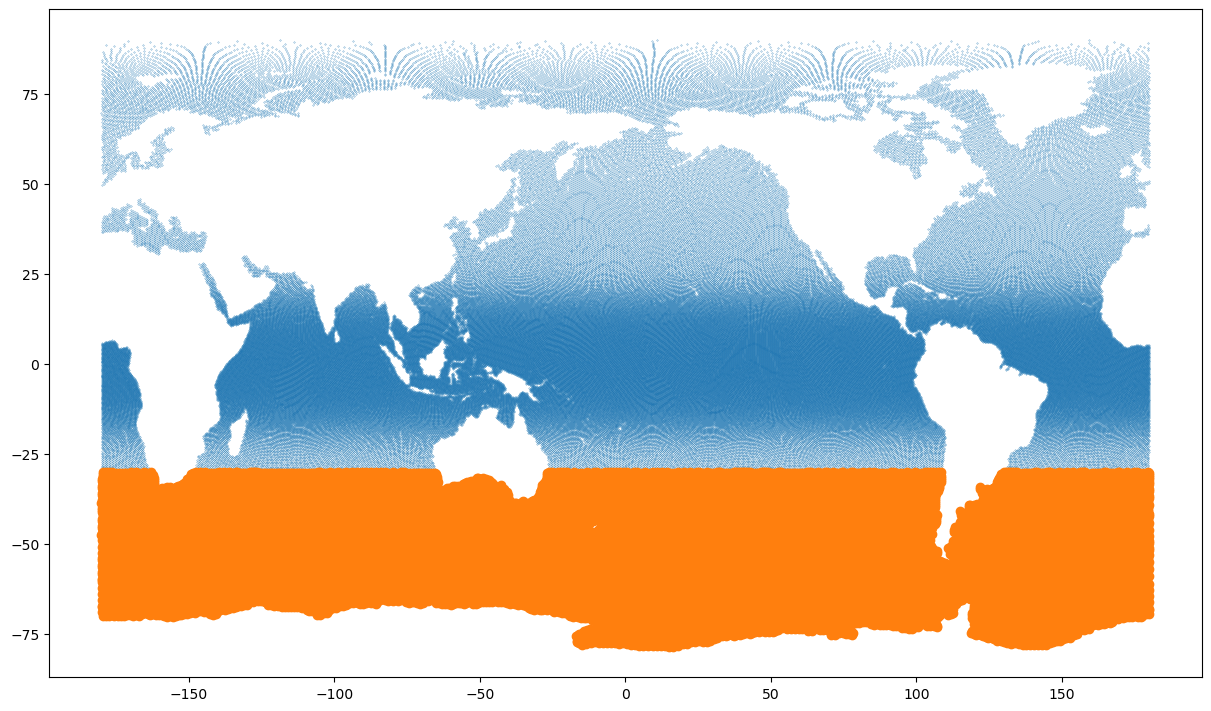

In [10]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True,figsize=(12,7))

ax.scatter(np.rad2deg(mesh.lonCell)-180,np.rad2deg(mesh.latCell),s=0.05)
ax.scatter(np.rad2deg(mesh.lonCell.where(dsMasks.regionCellMasks > 0))-180, np.rad2deg(mesh.latCell.where(dsMasks.regionCellMasks > 0)))

### create mask netcdf file (taken from `open_from_mask` function)

In [11]:
path = '/pscratch/sd/k/kuyeda/mpasregions/mpasregions/tests'
filename = 'test_MultiPolygon'
geojson_file_name = 'test_MultiPolygon'
tags = 'southOf30S'
author = 'Kaila Uyeda'

# dsMasks.to_netcdf(path + filename + '.nc', format='NETCDF4', mode='w')
# mask = xr.open_dataset(path + filename + '.nc')
mask_edges, mask_vertices, mask = mps.open_from_mask(ds,path,filename,geojson_file_name, tags, author)

Opening test_MultiPolygon.nc file as mask
switching transects at  1048
switching transects at  1054
switching transects at  1060
switching transects at  1220
switching transects at  1265
switching transects at  2916
switching transects at  2930
switching transects at  2936
switching transects at  2942
switching transects at  2948
switching transects at  2954
switching transects at  2960
switching transects at  2970
switching transects at  2976
switching transects at  2994


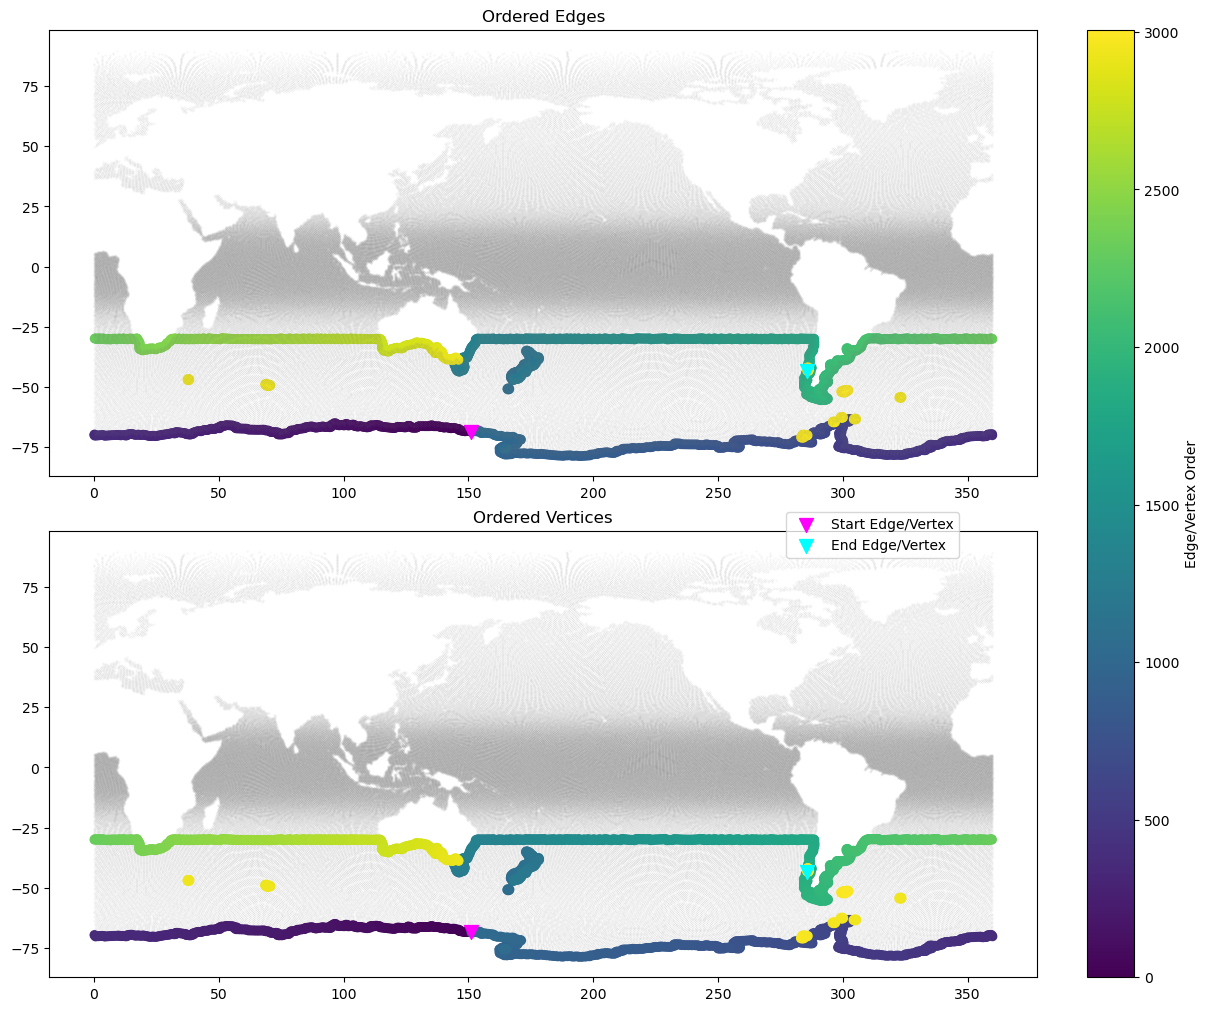

In [12]:
fig,ax = plt.subplots(nrows=2,ncols=1,constrained_layout=True,figsize=(12,10))


get_cbar = ax[0].scatter(np.rad2deg(mesh.lonEdge.isel(nEdges=np.int64(mask_edges))),np.rad2deg(mesh.latEdge.isel(nEdges=np.int64(mask_edges))),marker='o',c=np.arange(0,len(mask_edges)))
ax[0].scatter(np.rad2deg(mesh.lonCell),np.rad2deg(mesh.latCell),s=0.05,alpha=0.2,color='gray')
ax[0].scatter(np.rad2deg(mesh.lonEdge.isel(nEdges=np.int64(mask_edges[0]))),np.rad2deg(mesh.latEdge.isel(nEdges=np.int64(mask_edges[0]))),marker='v',color='Magenta',s=100)
ax[0].scatter(np.rad2deg(mesh.lonEdge.isel(nEdges=np.int64(mask_edges[-1]))),np.rad2deg(mesh.latEdge.isel(nEdges=np.int64(mask_edges[-1]))),marker='v',color='Cyan',s=100)
ax[0].set_title('Ordered Edges')

ax[1].scatter(np.rad2deg(mesh.lonCell),np.rad2deg(mesh.latCell),s=0.05,alpha=0.2,color='gray')
ax[1].scatter(np.rad2deg(mesh.lonVertex.isel(nVertices=np.int64(mask_vertices))),np.rad2deg(mesh.latVertex.isel(nVertices=np.int64(mask_vertices))),marker = 'o',c=np.arange(0,len(mask_edges)))
ax[1].scatter(np.rad2deg(mesh.lonVertex.isel(nVertices=np.int64(mask_vertices[0]))),np.rad2deg(mesh.latVertex.isel(nVertices=np.int64(mask_vertices[0]))),marker='v',color='Magenta',s=100,
             label='Start Edge/Vertex')
ax[1].scatter(np.rad2deg(mesh.lonVertex.isel(nVertices=np.int64(mask_vertices[-1]))),np.rad2deg(mesh.latVertex.isel(nVertices=np.int64(mask_vertices[-1]))),marker='v',color='Cyan',s=100,
             label='End Edge/Vertex')
ax[1].set_title('Ordered Vertices')

fig.colorbar(get_cbar,ax=ax,label='Edge/Vertex Order')
fig.legend(bbox_to_anchor=(0.8,0.5))


## Now calculate transports

In [13]:
ds_transect_edges_nCells, ds_transect_edges = mps.format_transect_data(ds, mask_edges)

In [15]:
ds_transect_edges_vIM = mps.calculate_transport_into_mask(ds_transect_edges_vIM)

Text(0.5, 1.0, 'Annual northward transport across 30$^\\circ$S')

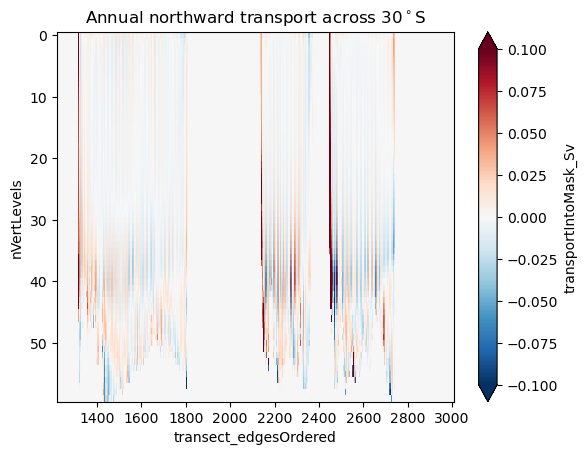

In [37]:
ds_transect_edges_vIM.transportIntoMask_Sv.isel(nEdges=slice(1220,3009)).mean(dim='xtime_startMonthly').swap_dims({'nEdges':'transect_edgesOrdered'}).plot(
    y='nVertLevels',vmin=-0.1,vmax=0.1,cmap='RdBu_r')
plt.gca().invert_yaxis()
plt.title('Annual northward transport across 30$^\\circ$S')

## attempt using Ben's ``_sort_edges`` function
As it turns out, I'm not entirely sure what happened, but I got back an array with -1 and ordered from 0-3007? I'm sure I could fiddle around with the inputs (outputs from `` mps.find_transect_edges_and_vertices(ds,dsMasks)``), but... idk

In [ ]:
sorted_edges = ben._sort_edges(xr_mask_transect_edges, np.array(ds.verticesOnEdge), np.array(ds.edgesOnVertex))
sorted_edges[sorted_edges != -1]
values,counts = np.unique_counts(sorted_edges)
sorted_edges